In [2]:
!pip install tqdm

In [3]:
!pip install symengine

In [5]:
import rebound
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import heyoka as hy
from celmech import Poincare, PoincareHamiltonian
from scipy import signal
import time
from tqdm import tqdm
import symengine as se

In [6]:
#constants and helper functions
m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

def ft(times, x):
    fs = 1/((times[1] - times[0])/(2*np.pi))
    f, pxx = signal.periodogram(x,fs=fs,window='hann',scaling='density')
    return f,pxx

def pomega_ft(times,pomega,ecc):
    k = ecc*np.cos(pomega)
    h = ecc*np.sin(pomega)*1j
    z = h + k
    f,pxx = ft(times, z)
    return f,pxx

#from celmech docs
def get_pomega(kap,eta):
    return np.arctan2(-eta,kap)

def get_ecc(kap,eta,L):
    P = (kap**2 + eta**2)/2
    return np.sqrt(1 - (1 - P/L)**2)

In [7]:
#heyoka integration

def hk_integrate(pham):
    #H_num = pham.H.subs(dict(pham.H_params))
    H_se = se.sympify(pham.H)
    clean_params_se = {se.sympify(k): v for k, v in dict(pham.H_params).items()
                   if not (hasattr(v, '__float__') and np.isnan(float(v)))}
    H_num = H_se.subs(clean_params_se)
    nan_symbols = {s: 0 for s in H_num.free_symbols 
               if str(s) not in {'Lambda1', 'Lambda2', 'eta1', 'eta2', 
                                  'kappa1', 'kappa2', 'lambda1', 'lambda2',
                                  'rho1', 'rho2', 'sigma1', 'sigma2'}}
    H_num = H_num.subs(nan_symbols)

    
    rho1,rho2,sigma1,sigma2 = se.symbols('rho1 rho2 sigma1 sigma2')
    sym_map = {s: 0 for s in H_num.free_symbols if str(s) in ('rho1', 'rho2', 'sigma1', 'sigma2')}
    H_planar = H_num.subs(sym_map)
    #H_planar = H_num.subs({rho1: 0, rho2: 0, sigma1: 0, sigma2: 0})
    H_planar = se.sympify(H_planar)
    print(sorted(str(s) for s in H_planar.free_symbols))

    lam1,lam2 = se.symbols('lambda1 lambda2')
    Lam1,Lam2 = se.symbols('Lambda1 Lambda2')
    eta1,eta2 = se.symbols('eta1 eta2')
    kap1, kap2 = se.symbols('kappa1 kappa2')

    print('*** Differentiating  ***')

    sym_dict = {str(s): s for s in H_planar.free_symbols}
    lam1 = sym_dict['lambda1']
    lam2 = sym_dict['lambda2']
    Lam1 = sym_dict['Lambda1']
    Lam2 = sym_dict['Lambda2']
    eta1 = sym_dict['eta1']
    eta2 = sym_dict['eta2']
    kap1 = sym_dict['kappa1']
    kap2 = sym_dict['kappa2']

    dLam1_dt = -se.diff(H_planar, lam1)
    dLam2_dt = -se.diff(H_planar, lam2)
    dlam1_dt =  se.diff(H_planar, Lam1)
    dlam2_dt =  se.diff(H_planar, Lam2)

    deta1_dt  = se.diff(H_planar, kap1)
    dkap1_dt  =  -se.diff(H_planar, eta1)
    deta2_dt  = se.diff(H_planar, kap2)
    dkap2_dt  =  -se.diff(H_planar, eta2)

    derivs = [dlam1_dt, dLam1_dt, dlam2_dt, dLam2_dt, deta1_dt, dkap1_dt, deta2_dt, dkap2_dt]

    vars_list = [lam1, Lam1, lam2, Lam2, eta1, kap1, eta2, kap2]
    func = se.Lambdify(vars_list,derivs)

    jup = pham.state.particles[1]
    sat = pham.state.particles[2]

    initial_conditions = [jup.l, jup.Lambda, sat.l, sat.Lambda,jup.eta, jup.kappa, sat.eta, sat.kappa]
    derivs_at_0 = func(*initial_conditions)

    lam1_hy, Lam1_hy, lam2_hy, Lam2_hy, eta1_hy, kap1_hy, eta2_hy, kap2_hy = hy.make_vars('lam1_hy', 'Lam1_hy', 'lam2_hy', 'Lam2_hy', 'eta1_hy', 'kap1_hy', 'eta2_hy', 'kap2_hy')

    eqs_hy = [hy.from_sympy(sp.sympify(eq), {sp.Symbol('lambda1'): lam1_hy, 
                                          sp.Symbol('Lambda1'): Lam1_hy,
                                          sp.Symbol('lambda2'): lam2_hy, 
                                          sp.Symbol('Lambda2'): Lam2_hy,
                                          sp.Symbol('eta1'): eta1_hy, 
                                          sp.Symbol('kappa1'): kap1_hy,
                                          sp.Symbol('eta2'): eta2_hy, 
                                          sp.Symbol('kappa2'): kap2_hy})
           for eq in derivs]

    ta = hy.taylor_adaptive(sys=[(lam1_hy, eqs_hy[0]),(Lam1_hy, eqs_hy[1]),(lam2_hy, eqs_hy[2]),(Lam2_hy, eqs_hy[3]),(eta1_hy,  eqs_hy[4]),(kap1_hy,  eqs_hy[5]),(eta2_hy,  eqs_hy[6]),(kap2_hy,  eqs_hy[7])],
    state=initial_conditions,
    high_accuracy= True,
    time=0.0,
    tol=1e-12)

    times = np.linspace(0,1e7,int(1e5))*2*np.pi
    e_sat = np.zeros(len(times))
    pomega_sat = np.zeros(len(times))

    start = time.perf_counter()
    print('*** Starting Simulation ***')
    for i in tqdm(range(len(times))):
        ta.propagate_until(times[i])
        L, eta, kap = ta.state[3], ta.state[6], ta.state[7]
        e_sat[i] = get_ecc(kap, eta, L)
        pomega_sat[i] = get_pomega(kap, eta)
        
    end = time.perf_counter()
        
    print('*** Simulation Complete ***')

    print('Time elapsed  = ' + str(end-start) + ' seconds')

    return times, pomega_sat, e_sat


In [4]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(5e3))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=9,q=4,indexIn=1, indexOut=2, max_order=5)

In [7]:
H_num = pham.H.subs(dict(pham.H_params))
print("Current Free symbols: " + str(H_num.free_symbols)) 

Current Free symbols: {Lambda2, eta2, eta1, kappa2, lambda2, Lambda1, sigma1, lambda1, kappa1, rho1, rho2, sigma2}


In [8]:
rho1,rho2,sigma1,sigma2 = sp.symbols('rho1 rho2 sigma1 sigma2')
H_planar = H_num.subs({rho1: 0, rho2: 0, sigma1: 0, sigma2: 0})

lam1,lam2 = sp.symbols('lamba1 lambda2')
Lam1,Lam2 = sp.symbols('Lamba1 Lambda2')
eta1,eta2 = sp.symbols('eta1 eta2')
kap1, kap2 = sp.symbols('kappa1 kapp2')

In [9]:
sym_dict = {str(s): s for s in H_planar.free_symbols}
lam1 = sym_dict['lambda1']
lam2 = sym_dict['lambda2']
Lam1 = sym_dict['Lambda1']
Lam2 = sym_dict['Lambda2']
eta1 = sym_dict['eta1']
eta2 = sym_dict['eta2']
kap1 = sym_dict['kappa1']
kap2 = sym_dict['kappa2']

dLam1_dt = -sp.diff(H_planar, lam1)
dLam2_dt = -sp.diff(H_planar, lam2)
dlam1_dt =  sp.diff(H_planar, Lam1)
dlam2_dt =  sp.diff(H_planar, Lam2)

deta1_dt  = sp.diff(H_planar, kap1)
dkap1_dt  =  -sp.diff(H_planar, eta1)
deta2_dt  = sp.diff(H_planar, kap2)
dkap2_dt  =  -sp.diff(H_planar, eta2)

derivs = [dlam1_dt, dLam1_dt, dlam2_dt, dLam2_dt, deta1_dt, dkap1_dt, deta2_dt, dkap2_dt]

In [10]:
vars = [lam1, Lam1, lam2, Lam2, eta1, kap1, eta2, kap2]
func = sp.lambdify(vars,derivs,'numpy')

jup = pham.state.particles[1]
sat = pham.state.particles[2]

initial_conditions = [jup.l, jup.Lambda, sat.l, sat.Lambda,jup.eta, jup.kappa, sat.eta, sat.kappa]
derivs_at_0 = func(*initial_conditions)

In [11]:
lam1_hy, Lam1_hy, lam2_hy, Lam2_hy, eta1_hy, kap1_hy, eta2_hy, kap2_hy = hy.make_vars('lam1_hy', 'Lam1_hy', 'lam2_hy', 'Lam2_hy', 'eta1_hy', 'kap1_hy', 'eta2_hy', 'kap2_hy')

eqs_hy = [hy.from_sympy(eq, {lam1: lam1_hy, Lam1: Lam1_hy,
                               lam2: lam2_hy, Lam2: Lam2_hy,
                               eta1: eta1_hy, kap1: kap1_hy,
                               eta2: eta2_hy, kap2: kap2_hy})
           for eq in derivs]


In [12]:
ta = hy.taylor_adaptive(sys=[(lam1_hy, eqs_hy[0]),(Lam1_hy, eqs_hy[1]),(lam2_hy, eqs_hy[2]),(Lam2_hy, eqs_hy[3]),(eta1_hy,  eqs_hy[4]),(kap1_hy,  eqs_hy[5]),(eta2_hy,  eqs_hy[6]),(kap2_hy,  eqs_hy[7])],
    state=initial_conditions,
    high_accuracy= True,
    time=0.0,
    tol=1e-12)

print(ta)

C++ datatype            : double
Tolerance               : 1e-12
High accuracy           : true
Compact mode            : false
Taylor order            : 15
Dimension               : 8
Time                    : 0
State                   : [0.24363402848677218, 0.0023522794299155967, 1.5490392859050166, 0.0008532031901639505, -0.0006914864975751438, 0.002821900429229676, -0.0009112940308177825, 3.295225000838225e-06]



In [13]:
times = np.linspace(0,1e7,int(1e5))*2*np.pi
e_sat = np.zeros(len(times))
pomega_sat = np.zeros(len(times))

start = time.perf_counter()
for i in range(len(times)):
    ta.propagate_until(times[i])
    L, eta, kap = ta.state[3], ta.state[6], ta.state[7]
    e_sat[i] = get_ecc(kap, eta, L)
    pomega_sat[i] = get_pomega(kap, eta)
end = time.perf_counter()

print(end-start)

13.461951419000115


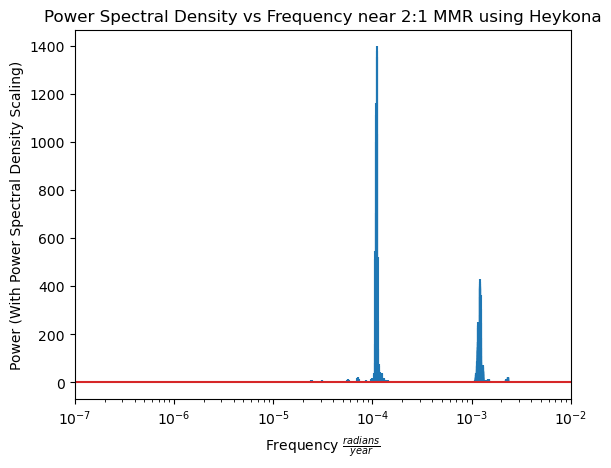

In [14]:
f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')
plt.show()

*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:30<00:00, 3324.72it/s]


*** Simulation Complete ***
Time elapsed  = 27.17434496299984 seconds


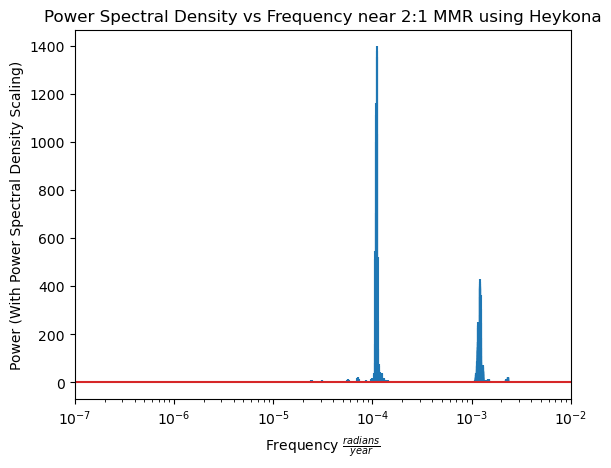

In [23]:
times, pomega_sat, e_sat = hk_integrate(pham)

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')
plt.show()

*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:39<00:00, 2511.23it/s]


*** Simulation Complete ***
Time elapsed  = 33.944278887999644 seconds


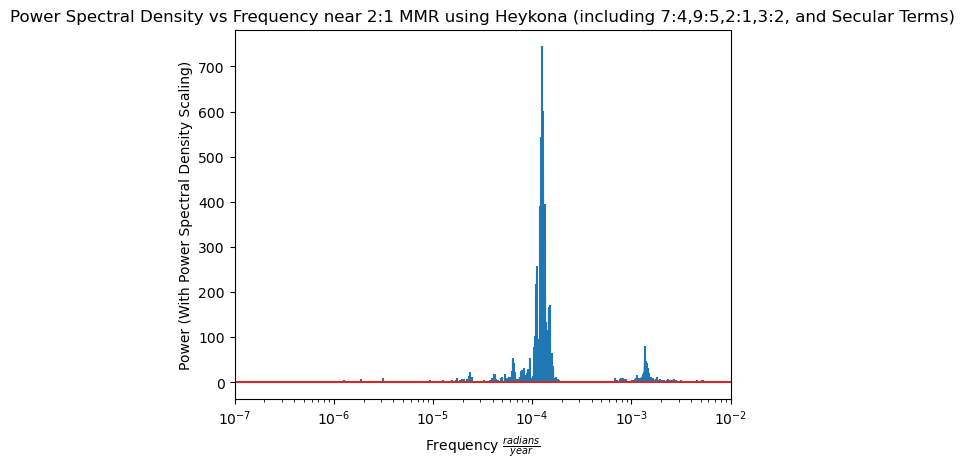

In [27]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(5e3))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=9,q=4,indexIn=1, indexOut=2, max_order=5)
pham.add_MMR_terms(p=7,q=3,indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=3,q=1, indexIn=1, indexOut=2, max_order=2)


times, pomega_sat, e_sat = hk_integrate(pham)

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heykona (including 7:4,9:5,2:1,3:2, and Secular Terms)')
plt.show()

*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:23<00:00, 4203.83it/s]


*** Simulation Complete ***
Time elapsed  = 23.790344353000364 seconds


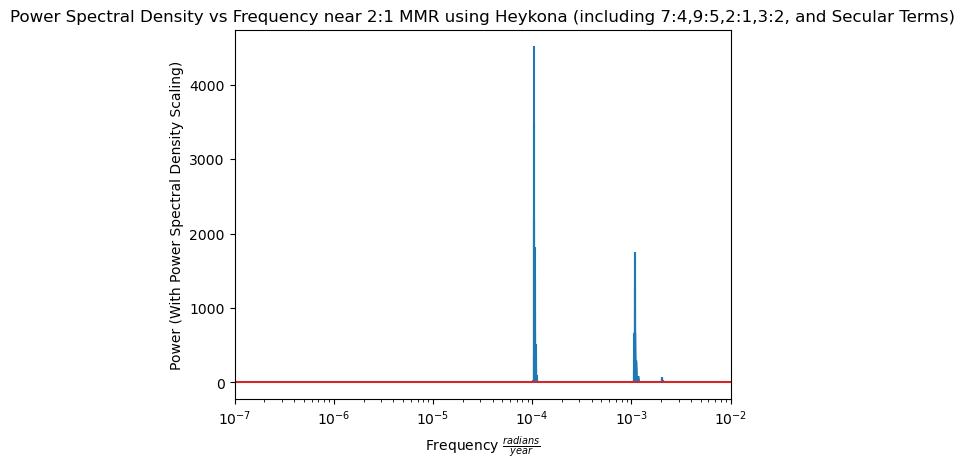

In [31]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(5e3))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=9,q=5,indexIn=1, indexOut=2, max_order=5)
pham.add_MMR_terms(p=7,q=4,indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=3,q=2, indexIn=1, indexOut=2, max_order=2)

times, pomega_sat, e_sat = hk_integrate(pham)

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heykona (including 7:4,9:5,2:1,3:2, and Secular Terms)')
plt.show()

*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:56<00:00, 1778.22it/s]


*** Simulation Complete ***
Time elapsed  = 53.30166942300002 seconds


Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heykona (including 7:4,9:5,2:1,3:2, and Secular Terms)')

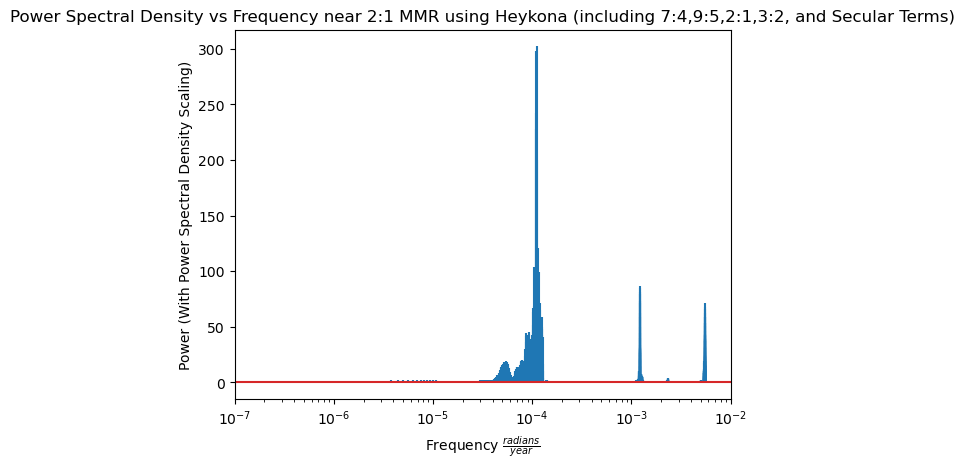

In [7]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(5e3))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=9,q=4,indexIn=1, indexOut=2, max_order=5)
pham.add_MMR_terms(p=7,q=3,indexIn=1, indexOut=2, max_order=3)
pham.add_MMR_terms(p=3,q=1, indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=11,q=6, indexIn=1, indexOut=2, max_order=6)

times, pomega_sat, e_sat = hk_integrate(pham)

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')

*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:58<00:00, 1723.02it/s]


*** Simulation Complete ***
Time elapsed  = 52.167405686000166 seconds


Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')

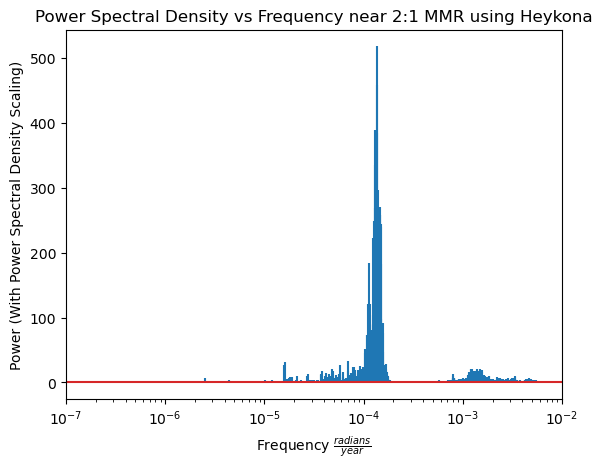

In [10]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(5e3))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=9,q=4,indexIn=1, indexOut=2, max_order=5)
pham.add_MMR_terms(p=7,q=3,indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=3,q=1, indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=13,q=6, indexIn=1, indexOut=2, max_order=6)


times, pomega_sat, e_sat = hk_integrate(pham)

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')

*** Starting Simulation ***


100%|██████████████████████████████████████████████████████████████████████████| 100000/100000 [01:49<00:00, 912.78it/s]


*** Simulation Complete ***
Time elapsed  = 101.80696937799996 seconds


Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')

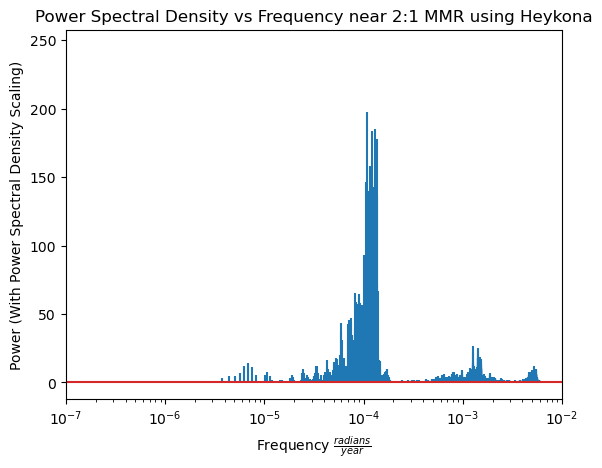

In [4]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(5e3))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=9,q=4,indexIn=1, indexOut=2, max_order=5)
pham.add_MMR_terms(p=9,q=5,indexIn=1, indexOut=2, max_order=5)
pham.add_MMR_terms(p=7,q=3,indexIn=1, indexOut=2, max_order=3)
pham.add_MMR_terms(p=7,q=4,indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=3,q=1, indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=3,q=2, indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=11,q=6, indexIn=1, indexOut=2, max_order=6)
pham.add_MMR_terms(p=13,q=6, indexIn=1, indexOut=2, max_order=6)
pham.add_MMR_terms(p=15,q=7, indexIn=1, indexOut=2, max_order=7)


times, pomega_sat, e_sat = hk_integrate(pham)

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Starting Simulation ***


100%|███████████████████████████████████████████████████████████████████████████| 100000/100000 [31:00<00:00, 53.74it/s]


*** Simulation Complete ***
Time elapsed  = 1705.1713659159996 seconds


Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')

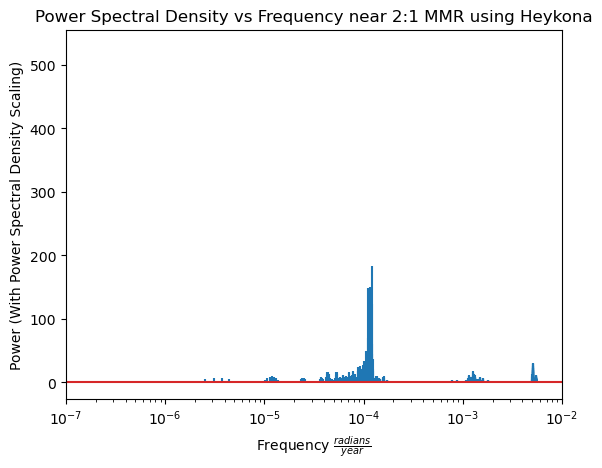

In [37]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(5e3))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=6)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=8)
pham.add_MMR_terms(p=9,q=4,indexIn=1, indexOut=2, max_order=5)
pham.add_MMR_terms(p=9,q=5,indexIn=1, indexOut=2, max_order=5)
pham.add_MMR_terms(p=7,q=3,indexIn=1, indexOut=2, max_order=3)
pham.add_MMR_terms(p=7,q=4,indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=3,q=1, indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=3,q=2, indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=5,q=2, indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=5,q=3, indexIn=1, indexOut=2, max_order=3)
pham.add_MMR_terms(p=11,q=6, indexIn=1, indexOut=2, max_order=6)
pham.add_MMR_terms(p=13,q=6, indexIn=1, indexOut=2, max_order=6)
pham.add_MMR_terms(p=15,q=7, indexIn=1, indexOut=2, max_order=7)


times, pomega_sat, e_sat = hk_integrate(pham)

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')